In [116]:
# Heart Disease Prediction Project
### Author: [Melih Talha Akbalık]
### Objective: Binary classification to predict heart disease using the CDC 2015 BRFSS dataset.

## --- STEP 1: LIBRARIES ---





In [117]:
#Here are the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## --- STEP 2: ACCESING DATA ---

In [118]:
path = '/content/sample_data/heart.csv'
df = pd.read_csv(path)

# Check for any missing values
quality_report = df.isnull().sum().to_frame(name='Missing Values')
quality_report['Percentage (%)'] = (quality_report['Missing Values'] / len(df)) * 100

print("--- DATA QUALITY & INTEGRITY REPORT ---")
# Gradient coloring helps to quickly spot any missing data
display(quality_report.style.background_gradient(cmap='Reds'))

print(f"\nFinal Dataset Dimensions: {df.shape}")

--- DATA QUALITY & INTEGRITY REPORT ---


,Missing Values,Percentage (%)
HeartDiseaseorAttack,0,0.000000
HighBP,0,0.000000
HighChol,0,0.000000
CholCheck,0,0.000000
BMI,0,0.000000
Smoker,0,0.000000
Stroke,0,0.000000
Diabetes,0,0.000000
PhysActivity,0,0.000000
Fruits,0,0.000000



Final Dataset Dimensions: (253680, 22)


## --- STEP 3: DATA PREPROCESSING ---

In [119]:
X = df.drop('HeartDiseaseorAttack', axis=1)
y = df['HeartDiseaseorAttack']

# Stratified Split (80% Train / 20% Test)
# Stratify ensures the minority class ratio is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling: Z-score Normalization (Mean=0, Std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled for modeling.")

Data successfully split and scaled for modeling.


## --- STEP 4: MODEL TRAINING ---

In [120]:
# Baseline Model: Logistic Regression (Interpretable)
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Advanced Model: Random Forest (Non-linear & Robust)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12,
                                   class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Both Logistic Regression and Random Forest models are trained.")

Both Logistic Regression and Random Forest models are trained.


## --- STEP 5: PERFORMANCE BENCHMARK ---

In [121]:
# --- STEP 5: PERFORMANCE BENCHMARKING ---
from sklearn.metrics import roc_auc_score

def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ]

# Constructing the Benchmark Table
results = pd.DataFrame({
    "Performance Metric": ["Accuracy", "Precision", "Recall (Sensitivity)", "F1-Score", "ROC-AUC"],
    "Logistic Regression": get_metrics(lr_model, X_test_scaled, y_test),
    "Random Forest": get_metrics(rf_model, X_test_scaled, y_test)
})

print("\n--- CLINICAL CLASSIFICATION COMPARISON ---")
display(results.style.format(precision=4).background_gradient(cmap='YlGn'))


--- CLINICAL CLASSIFICATION COMPARISON ---


,Performance Metric,Logistic Regression,Random Forest
0,Accuracy,0.7534,0.7717
1,Precision,0.2482,0.2564
2,Recall (Sensitivity),0.7970,0.7497
3,F1-Score,0.3785,0.3822
4,ROC-AUC,0.8470,0.8424


# --- STEP 6: MODEL EXPLAINABILITY & ERROR ANALYSIS ---

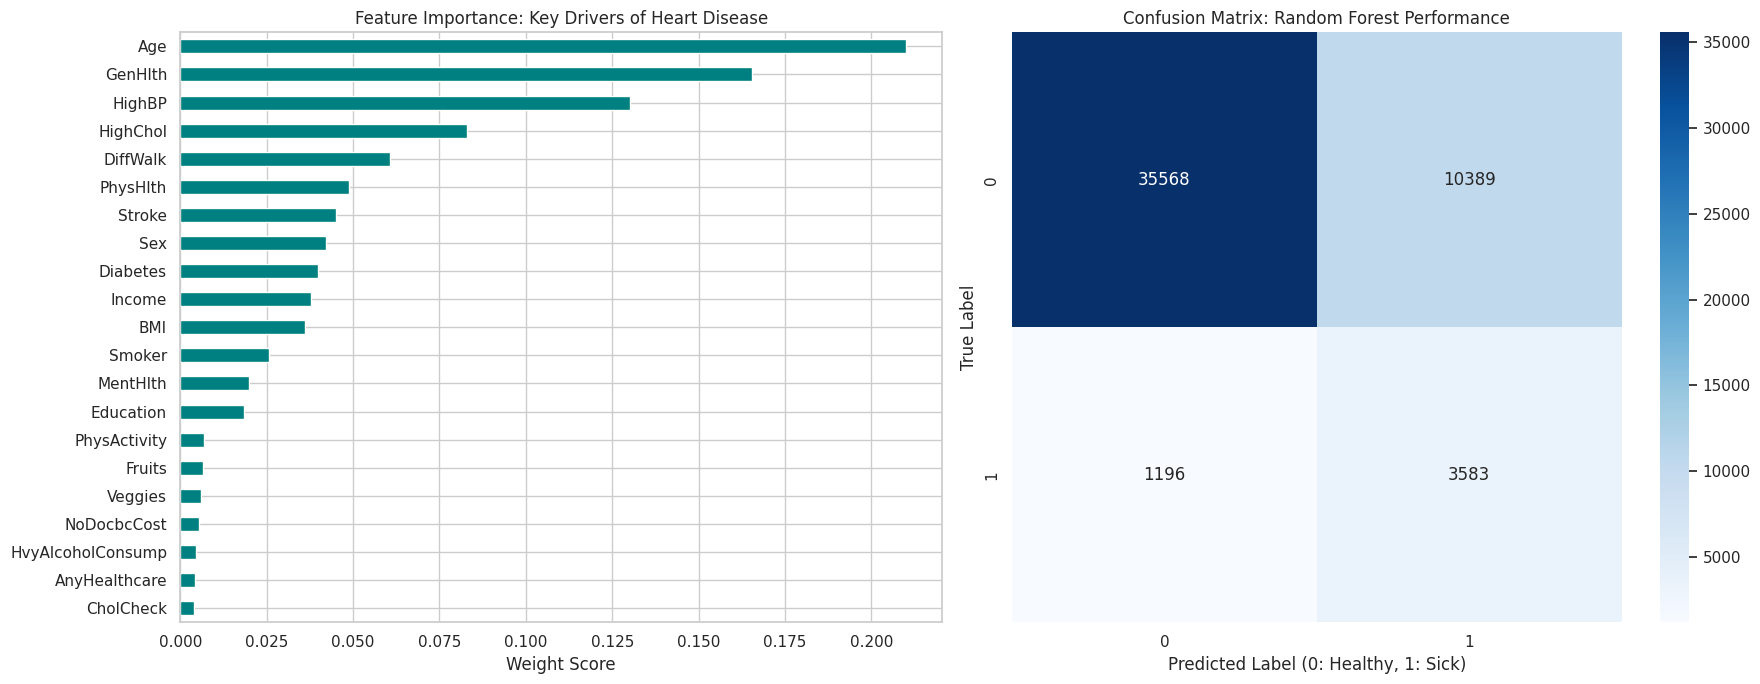

In [122]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# 1. Feature Importance (Explainable AI)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='teal', ax=ax[0])
ax[0].set_title('Feature Importance: Key Drivers of Heart Disease')
ax[0].set_xlabel('Weight Score')

# 2. Confusion Matrix (Error Distribution)
cm = confusion_matrix(y_test, rf_model.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix: Random Forest Performance')
ax[1].set_xlabel('Predicted Label (0: Healthy, 1: Sick)')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()